## Tahap 1: Import Libraries
Langkah pertama adalah mengimpor semua library yang kita butuhkan.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import ast

# Untuk Content-Based
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Untuk Collaborative Filtering
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

## Tahap 2: Load Data

Kita muat data `movies.csv` dan `ratings.csv` dari folder `ml-latest-small/`.
(Pastikan folder `ml-latest-small` ada di tempat yang sama dengan file notebook ini).


Mencoba memuat data...
Data berhasil dimuat!

--- 5 Baris Pertama Data Movies Metadata ---
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt011

/var/folders/22/vjvqz6_x6kz8rq98kfv76d100000gp/T/ipykernel_85604/3540276953.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_df_raw, palette='viridis')


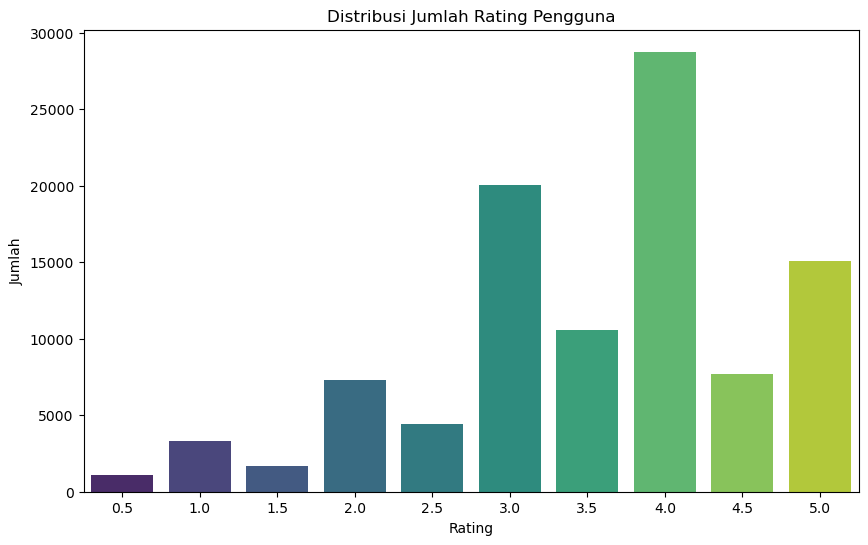

Insight: Rating 4.0 adalah yang paling umum. Pengguna cenderung memberi rating tinggi.


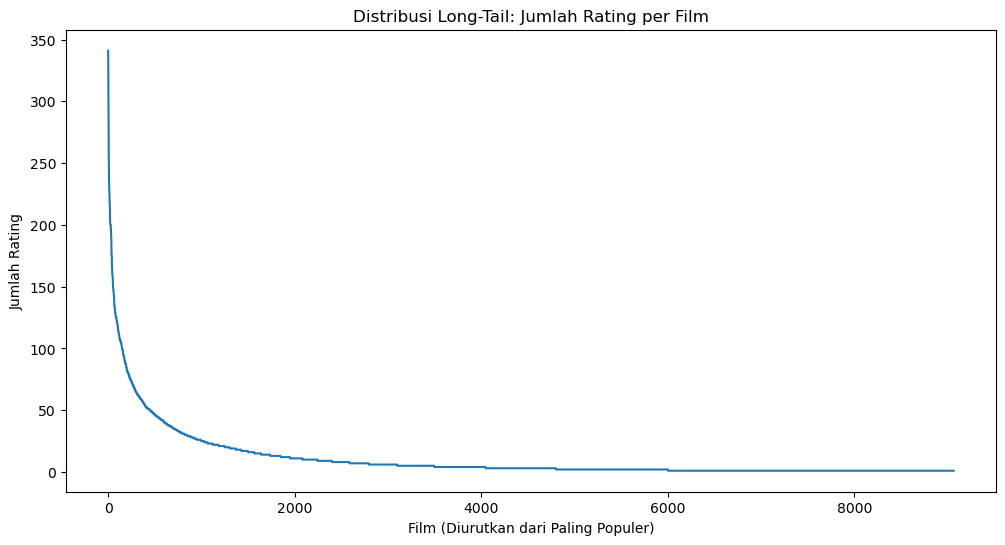


INSIGHT PENTING (Long-Tail):
Grafik ini menunjukkan bahwa sebagian kecil film (di kiri) mendapatkan mayoritas rating.
Sebagian besar film (di kanan) hampir tidak memiliki rating.
Model yang HANYA bergantung pada popularitas (Collaborative Filtering) akan gagal merekomendasikan film di 'long-tail' ini.

MASALAH 'COLD START':
1. Bagaimana cara merekomendasikan FILM BARU yang belum punya rating? (Masalah 'Long-Tail')
2. Bagaimana cara memberi rekomendasi pada PENGGUNA BARU yang belum punya histori? (Masalah 'User Cold Start')

KESIMPULAN EDA: Kita tidak bisa bergantung pada SATU model saja. Kita butuh:
1. Content-Based: Untuk mengatasi 'Cold Start' film baru (pakai plot, aktor, sutradara).
2. Collaborative Filtering: Untuk personalisasi akurat berdasarkan selera pengguna lain.
==> SOLUSI: MODEL HIBRIDA.


In [100]:
# LOAD DATA
# ---------------------------------
# Tentukan path ke folder data
# GANTI PATH INI sesuai dengan lokasi folder Anda
DATA_DIR = 'movies-dataset/' 

print("\nMencoba memuat data...")

try:
    # Kita load data film, kredit, dan rating
    movies_df_raw = pd.read_csv(os.path.join(DATA_DIR, 'movies_metadata.csv'), low_memory=False)
    credits_df_raw = pd.read_csv(os.path.join(DATA_DIR, 'credits.csv'))
    # Gunakan ratings_small.csv agar ringan
    ratings_df_raw = pd.read_csv(os.path.join(DATA_DIR, 'ratings_small.csv'))
    print("Data berhasil dimuat!")
except FileNotFoundError as e:
    print(f"Error: File tidak ditemukan. Pastikan path '{DATA_DIR}' benar dan berisi file .csv")
    print(e)

print("\n--- 5 Baris Pertama Data Movies Metadata ---")
print(movies_df_raw.head())

print("\n--- 5 Baris Pertama Data Credits ---")
print(credits_df_raw.head())

print("\n--- 5 Baris Pertama Data Ratings ---")
print(ratings_df_raw.head())

print("\n--- Info Movies Metadata ---")
movies_df_raw.info()
print("\n--- Info Credits ---")
credits_df_raw.info()
print("\n--- Info Ratings ---")
ratings_df_raw.info()

# ---------------------------------
# EDA (EXPLORATORY DATA ANALYSIS)
# ---------------------------------
print("\n--- Statistik Deskriptif Data Ratings ---")
print(ratings_df_raw['rating'].describe())

# Melihat distribusi rating
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings_df_raw, palette='viridis')
plt.title('Distribusi Jumlah Rating Pengguna')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.show()
print("Insight: Rating 4.0 adalah yang paling umum. Pengguna cenderung memberi rating tinggi.")

# Visualisasi Masalah 'Long-Tail'
plt.figure(figsize=(12, 6))
ratings_per_movie = ratings_df_raw.groupby('movieId').size()
ratings_per_movie.sort_values(ascending=False).plot(kind='line', use_index=False)
plt.title('Distribusi Long-Tail: Jumlah Rating per Film')
plt.xlabel('Film (Diurutkan dari Paling Populer)')
plt.ylabel('Jumlah Rating')
plt.show()

print("\nINSIGHT PENTING (Long-Tail):")
print("Grafik ini menunjukkan bahwa sebagian kecil film (di kiri) mendapatkan mayoritas rating.")
print("Sebagian besar film (di kanan) hampir tidak memiliki rating.")
print("Model yang HANYA bergantung pada popularitas (Collaborative Filtering) akan gagal merekomendasikan film di 'long-tail' ini.")

print("\nMASALAH 'COLD START':")
print("1. Bagaimana cara merekomendasikan FILM BARU yang belum punya rating? (Masalah 'Long-Tail')")
print("2. Bagaimana cara memberi rekomendasi pada PENGGUNA BARU yang belum punya histori? (Masalah 'User Cold Start')")

print("\nKESIMPULAN EDA: Kita tidak bisa bergantung pada SATU model saja. Kita butuh:")
print("1. Content-Based: Untuk mengatasi 'Cold Start' film baru (pakai plot, aktor, sutradara).")
print("2. Collaborative Filtering: Untuk personalisasi akurat berdasarkan selera pengguna lain.")
print("==> SOLUSI: MODEL HIBRIDA.")


# Tahap 4: Data Cleansing & Feature Selection

Data kita sebenarnya sudah cukup bersih (tidak ada null). Namun, untuk model Content-Based, kita perlu membersihkan kolom `genres`.

Feature Selection:

* **Content-Based**: Kita akan menggunakan `genres` sebagai fitur utama. title sebagai identifier.

* **Collaborative**: Kita akan menggunakan `userId`, `movieId`, dan `rating`.

In [101]:
# Backup data mentah - BIASANYA DIPISAH di sel terpisah
movies_df = movies_df_raw.copy()
credits_df = credits_df_raw.copy()
ratings_df = ratings_df_raw.copy()


In [102]:
# 1. Bersihin movies_df dulu
print("Membersihkan movies_df...")
movies_df['id'] = pd.to_numeric(movies_df['id'], errors='coerce')  # Ubah ke angka, yang error jadi NaN
movies_df = movies_df.dropna(subset=['id'])  # Buang baris yang id-nya NaN
movies_df['id'] = movies_df['id'].astype(int)  # Pastikan id integer

# 2. Pastikan credits_df juga bersih
print("Membersihkan credits_df...")
credits_df['id'] = credits_df['id'].astype(int)

# 3. Gabungkan kedua data
print("Menggabungkan movies dan credits...")
print(f"Shape movies sebelum merge: {movies_df.shape}")
print(f"Shape credits sebelum merge: {credits_df.shape}")

movies_df_merged = pd.merge(movies_df, credits_df, on='id')

print(f"Shape setelah merge: {movies_df_merged.shape}")
print("Gabungan berhasil! Sekarang ada kolom 'cast' dan 'crew'")

Membersihkan movies_df...
Membersihkan credits_df...
Menggabungkan movies dan credits...
Shape movies sebelum merge: (45463, 24)
Shape credits sebelum merge: (45476, 3)
Shape setelah merge: (45538, 26)
Gabungan berhasil! Sekarang ada kolom 'cast' dan 'crew'


In [103]:
# Feature engineering

# Bikin fungsi-fungsi helper dulu
def safe_literal_eval(s):
    if pd.isna(s):
        return []
    try:
        return ast.literal_eval(s)
    except:
        return []

def get_director(crew_list):
    for person in crew_list:
        if person.get('job') == 'Director':
            return person.get('name', '').replace(' ', '').lower()
    return ''

def get_top_n_cast(cast_list, n=3):
    names = []
    for i, actor in enumerate(cast_list):
        if i < n:
            names.append(actor.get('name', '').replace(' ', '').lower())
        else:
            break
    return names

def get_genre_names(genre_list):
    return [genre.get('name', '').replace(' ', '').lower() for genre in genre_list]

# Ubah string JSON jadi list/dict Python
movies_df_merged['genres'] = movies_df_merged['genres'].apply(safe_literal_eval)
movies_df_merged['cast'] = movies_df_merged['cast'].apply(safe_literal_eval)
movies_df_merged['crew'] = movies_df_merged['crew'].apply(safe_literal_eval)

# Ekstrak fitur-fitur baru
movies_df_merged['genres_clean'] = movies_df_merged['genres'].apply(get_genre_names)
movies_df_merged['director'] = movies_df_merged['crew'].apply(get_director)
movies_df_merged['cast_clean'] = movies_df_merged['cast'].apply(get_top_n_cast)
movies_df_merged['overview'] = movies_df_merged['overview'].fillna('')  # Isi yang kosong

movies_df_merged[['title', 'genres_clean', 'director', 'cast_clean']].head(2)

,title,genres_clean,director,cast_clean
0,Toy Story,"[animation, comedy, family]",johnlasseter,"[tomhanks, timallen, donrickles]"
1,Jumanji,"[adventure, fantasy, family]",joejohnston,"[robinwilliams, jonathanhyde, kirstendunst]"


In [104]:
# Buat content soup
def buat_soup(row):
    """Gabungkan semua fitur jadi satu teks panjang"""
    plot = row['overview'].lower().split()
    genres = ' '.join(row['genres_clean'] * 3)  # Genre lebih penting (x3)
    director = ' '.join([row['director']] * 2)  # Sutradara penting (x2)  
    cast = ' '.join(row['cast_clean'] * 2)      # Aktor penting (x2)
    
    return ' '.join(plot) + ' ' + genres + ' ' + director + ' ' + cast

movies_df_merged['content_soup'] = movies_df_merged.apply(buat_soup, axis=1)

movies_df_merged.head(2)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,title,video,vote_average,vote_count,cast,crew,genres_clean,director,cast_clean,content_soup
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[animation, comedy, family]",johnlasseter,"[tomhanks, timallen, donrickles]","led by woody, andy's toys live happily in his ..."
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[adventure, fantasy, family]",joejohnston,"[robinwilliams, jonathanhyde, kirstendunst]",when siblings judy and peter discover an encha...


In [105]:
# Pilih kolom yang kita butuhkan aja
movies_df_clean = movies_df_merged[[
    'id', 
    'title', 
    'overview', 
    'genres_clean', 
    'director', 
    'cast_clean', 
    'content_soup'
]].copy()

# Ubah id jadi string biar match dengan ratings nanti
movies_df_clean['id'] = movies_df_clean['id'].astype(str)

In [106]:
movies_df_clean.head()

,id,title,overview,genres_clean,director,cast_clean,content_soup
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[animation, comedy, family]",johnlasseter,"[tomhanks, timallen, donrickles]","led by woody, andy's toys live happily in his ..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[adventure, fantasy, family]",joejohnston,"[robinwilliams, jonathanhyde, kirstendunst]",when siblings judy and peter discover an encha...
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[romance, comedy]",howarddeutch,"[waltermatthau, jacklemmon, ann-margret]",a family wedding reignites the ancient feud be...
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[comedy, drama, romance]",forestwhitaker,"[whitneyhouston, angelabassett, lorettadevine]","cheated on, mistreated and stepped on, the wom..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,[comedy],charlesshyer,"[stevemartin, dianekeaton, martinshort]",just when george banks has recovered from his ...


# Tahap 5: Pemodelan (Bagian 1 - Content-Based)

Kita akan membangun model yang merekomendasikan film berdasarkan kemiripan genre.

Ubah genres_clean menjadi angka menggunakan TF-IDF.

Hitung kemiripan antar semua film menggunakan Cosine Similarity.

In [107]:
# Menyiapkan TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# .fit_transform() 'soup' 
tfidf_matrix = tfidf.fit_transform(movies_df_clean['content_soup'])
print(tfidf_matrix.shape)

# CATATAN PENTING:
# Tidak hitung cosine_similarity(tfidf_matrix, tfidf_matrix) di sini
# Cosine Similarity menghasilkan 45000 x 45000 yang yang terlalu besar
# Hitung similarity-nya saat dibutuhin saja di aplikasi Streamlit (on the fly)

(45538, 138264)


# Tahap 6: Pemodelan (Bagian 2 - Collaborative Filtering)

Sekarang kita buat model berdasarkan rating pengguna. Kita akan pakai library Surprise dan algoritma SVD.

In [108]:
reader = Reader(rating_scale=(0.5, 5.0))

# Pastikan 'movieId' adalah string agar bisa dicocokkan dengan 'id' film kita nanti
ratings_df['movieId'] = ratings_df['movieId'].astype(str)
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)

# melatih SVD pada SELURUH dataset (Full Trainset) agar modelnya sepintar mungkin
full_trainset = data.build_full_trainset()
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42)

svd_model.fit(full_trainset)


## Evaluasi Model SVD

Sebelum kita melatih di semua data, mari kita cek seberapa bagus model SVD ini. Kita pakai cross_validate.
Kita ingin melihat RMSE (Root Mean Squared Error). Semakin kecil (mendekati 0), semakin bagus.

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9038  0.9048  0.8968  0.9018  0.0036  
MAE (testset)     0.6974  0.6970  0.6907  0.6950  0.0030  
Fit time          0.25    0.22    0.22    0.23    0.02    
Test time         0.05    0.07    0.05    0.05    0.01    

Hasil Evaluasi Selesai.
Rata-rata RMSE: 0.9018
Rata-rata MAE: 0.6950


/var/folders/22/vjvqz6_x6kz8rq98kfv76d100000gp/T/ipykernel_85604/2997616553.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['test_rmse'], palette='plasma')
/var/folders/22/vjvqz6_x6kz8rq98kfv76d100000gp/T/ipykernel_85604/2997616553.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['test_mae'], palette='cividis')


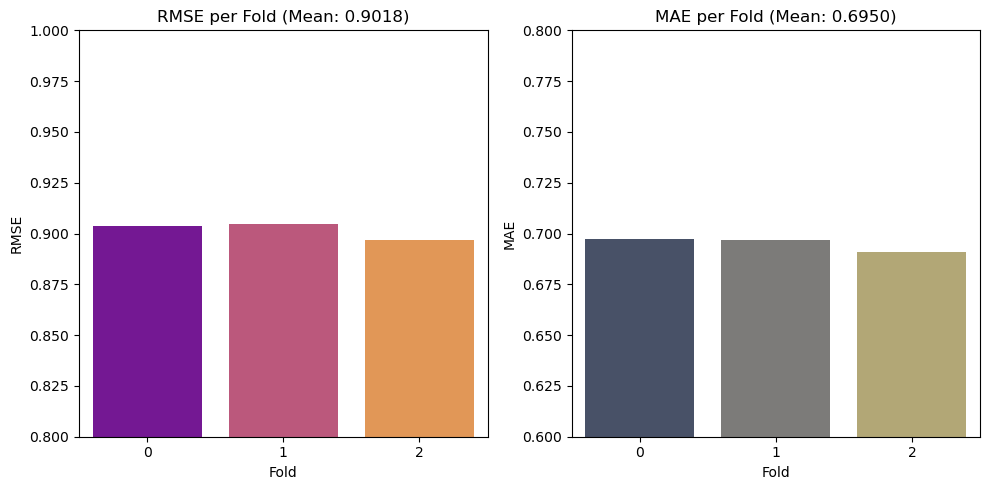


Interpretasi: Hasil RMSE ~0.9 sangat baik. Ini berarti model kita rata-rata hanya salah menebak rating sebesar 0.9 poin (dalam skala 1-5).


In [109]:
#3-fold Cross-Validation untuk SVD

svd_eval = SVD(n_factors=100, n_epochs=20, random_state=42)

# Jalankan cross-validate pada 'data' (bukan 'full_trainset')
evaluation_results = cross_validate(svd_eval, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

print("\nHasil Evaluasi Selesai.")
mean_rmse = evaluation_results['test_rmse'].mean()
mean_mae = evaluation_results['test_mae'].mean()
print(f"Rata-rata RMSE: {mean_rmse:.4f}")
print(f"Rata-rata MAE: {mean_mae:.4f}")

# Visualisasi hasil evaluasi
results_df = pd.DataFrame.from_dict(evaluation_results)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=results_df.index, y=results_df['test_rmse'], palette='plasma')
plt.title(f'RMSE per Fold (Mean: {mean_rmse:.4f})')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.ylim(0.8, 1.0) # Set limit Y agar perbedaan terlihat jelas

plt.subplot(1, 2, 2)
sns.barplot(x=results_df.index, y=results_df['test_mae'], palette='cividis')
plt.title(f'MAE per Fold (Mean: {mean_mae:.4f})')
plt.xlabel('Fold')
plt.ylabel('MAE')
plt.ylim(0.6, 0.8)

plt.tight_layout()
plt.show()

print("\nInterpretasi: Hasil RMSE ~0.9 sangat baik. Ini berarti model kita rata-rata hanya salah menebak rating sebesar 0.9 poin (dalam skala 1-5).")


## Melatih Model SVD (Full Trainset)

Karena kita tahu modelnya cukup bagus (RMSE < 0.9), sekarang kita latih modelnya menggunakan SEMUA data rating agar modelnya sepintar mungkin untuk deployment.

In [110]:
# 1. Membangun trainset dari semua data
full_trainset = data.build_full_trainset()

# 2. Inisialisasi model SVD (parameter sama)
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42)

# 3. Melatih model
svd_model.fit(full_trainset)


# Tahap 7: Uji Coba Rekomendasi (Hybrid)

Sekarang bagian serunya! Mari kita coba dapatkan rekomendasi untuk 1 user.

Skenario:

Pilih 1 User (misal: userId = 1).

Ambil 5 film yang paling dia SUKAI (rating tertinggi).

Cari rekomendasi Content-Based berdasarkan 5 film itu.

Cari rekomendasi Collaborative untuk user itu.

Gabungkan keduanya (Hybrid)!

In [111]:
# --- 1. Definisikan Fungsi Helper (Sama seperti di app.py) ---
# Kita perlu mendefinisikannya di sini agar bisa kita panggil

# Buat dulu mapping 'judul' ke 'index' yang akan kita butuhkan
try:
    indices_map = pd.Series(movies_df_clean.index, index=movies_df_clean['title'])
    print("[INFO] 'indices_map' (Judul -> Index) berhasil dibuat.")
except Exception as e:
    print(f"[ERROR] Gagal membuat indices_map: {e}")

def get_content_based_recommendations(liked_movie_titles, n_recommendations, movies_df, tfidf_matrix, indices_map):
    """
    Menghasilkan rekomendasi Content-Based secara on-the-fly.
    Versi non-Streamlit.
    """
    try:
        liked_indices = [indices_map[title] for title in liked_movie_titles if title in indices_map]
        if not liked_indices:
            return pd.DataFrame(columns=['title', 'score_cb'])
        
        liked_vectors = tfidf_matrix[liked_indices]
        cosine_sim_matrix = cosine_similarity(liked_vectors, tfidf_matrix)
        avg_sim_scores = cosine_sim_matrix.mean(axis=0)
        sim_scores_list = list(enumerate(avg_sim_scores))
        sim_scores_list = sorted(sim_scores_list, key=lambda x: x[1], reverse=True)
        
        recommendations = []
        for i, score in sim_scores_list:
            movie_title = movies_df.iloc[i]['title']
            if movie_title not in liked_movie_titles:
                recommendations.append({'title': movie_title, 'score_cb': score})
            if len(recommendations) >= (n_recommendations * 10): # Ambil 10x lebih banyak
                break
        return pd.DataFrame(recommendations)
    except Exception as e:
        print(f"[ERROR] di Content-Based: {e}")
        return pd.DataFrame(columns=['title', 'score_cb'])

def get_collaborative_filtering_recommendations(user_id, n_recommendations, movies_df, ratings_df, svd_model):
    """
    Menghasilkan rekomendasi Collaborative Filtering (SVD).
    Versi non-Streamlit.
    """
    try:
        watched_movie_ids = ratings_df[ratings_df['userId'] == user_id]['movieId'].unique()
        all_movie_ids = movies_df['id'].unique()
        to_predict_movie_ids = np.setdiff1d(all_movie_ids, watched_movie_ids)
        
        if len(to_predict_movie_ids) == 0:
            print(f"Warning: User {user_id} sudah menonton semua film di dataset!")
            return pd.DataFrame(columns=['title', 'score_cf'])

        testset = [[user_id, movie_id, 4.0] for movie_id in to_predict_movie_ids]
        predictions = svd_model.test(testset)
        predictions.sort(key=lambda x: x.est, reverse=True)
        
        recommendations = []
        for pred in predictions[:n_recommendations * 10]: # Ambil 10x lebih banyak
            movie_id = pred.iid
            movie_title_series = movies_df[movies_df['id'] == movie_id]['title']
            if not movie_title_series.empty:
                movie_title = movie_title_series.values[0]
                recommendations.append({'title': movie_title, 'score_cf': pred.est})
        return pd.DataFrame(recommendations)
    except Exception as e:
        print(f"[ERROR] di Collaborative Filtering: {e}")
        return pd.DataFrame(columns=['title', 'score_cf'])

[INFO] 'indices_map' (Judul -> Index) berhasil dibuat.


In [112]:
# --- 2. Jalankan Pengujian ---

# Variabel yang diuji (diambil dari memori notebook)
# - svd_model
# - tfidf_matrix
# - movies_df_clean
# - ratings_df
# - indices_map

TEST_USER_ID = 1
N_RECS = 20

# Kita ambil 3 film pertama dari data bersih sebagai 'film favorit'
TEST_MOVIES = movies_df_clean['title'].head(3).tolist() 

print(f"\n[INFO] Variabel tes dimuat:")
print(f"[INFO] User ID: {TEST_USER_ID}")
print(f"[INFO] Film Favorit: {TEST_MOVIES}")

# --- Tes 1: Collaborative Filtering ---
print(f"\n--- TES 1: Collaborative Filtering untuk User {TEST_USER_ID} (Top {N_RECS}) ---")
cf_recs = get_collaborative_filtering_recommendations(TEST_USER_ID, N_RECS, movies_df_clean, ratings_df, svd_model)
print(cf_recs.head(N_RECS))
assert not cf_recs.empty, "Test CF Gagal, DataFrame kosong!"
print("[SUCCESS] Tes Collaborative Filtering Lolos.")


[INFO] Variabel tes dimuat:
[INFO] User ID: 1
[INFO] Film Favorit: ['Toy Story', 'Jumanji', 'Grumpier Old Men']

--- TES 1: Collaborative Filtering untuk User 1 (Top 20) ---
                                                title  score_cf
0                                Sleepless in Seattle  3.585117
1                                   Dog Day Afternoon  3.534598
2                          Far from the Madding Crowd  3.529573
3                             While You Were Sleeping  3.507996
4                            The Million Dollar Hotel  3.493599
5                                 Birdman of Alcatraz  3.484102
6                                    Dawn of the Dead  3.472818
7                                     Men in Black II  3.467756
8                                    Kindergarten Cop  3.454729
9                                     Broken Blossoms  3.446442
10  Shriek If You Know What I Did Last Friday the ...  3.437966
11                                  The Good Shepherd  3.

In [113]:
# --- Tes 2: Content-Based ---
print(f"\n--- TES 2: Content-Based berdasarkan {len(TEST_MOVIES)} film (Top {N_RECS}) ---")
cb_recs = get_content_based_recommendations(TEST_MOVIES, N_RECS, movies_df_clean, tfidf_matrix, indices_map)
print(cb_recs.head(N_RECS))
assert not cb_recs.empty, "Test CB Gagal, DataFrame kosong!"
print("[SUCCESS] Tes Content-Based Lolos.")


--- TES 2: Content-Based berdasarkan 3 film (Top 20) ---
                              title  score_cb
0                       Toy Story 2  0.206987
1                       Toy Story 3  0.190927
2                    Grumpy Old Men  0.162572
3                 The Odd Couple II  0.140393
4                   Superstar Goofy  0.139350
5                       Cheburashka  0.119374
6                   Partysaurus Rex  0.116592
7                         Small Fry  0.110152
8              Toy Story of Terror!  0.097778
9                    The Front Page  0.096750
10       Toy Story That Time Forgot  0.096489
11                          Aladdin  0.093447
12  Blank: A Vinylmation Love Story  0.092664
13                             Hook  0.092423
14                   The Pagemaster  0.090186
15                           Cars 2  0.090182
16             Wow! A Talking Fish!  0.089485
17             The Pleasure Seekers  0.089139
18                The Polar Express  0.088181
19                    

In [114]:
# --- Tes 3: Hybrid (Simulasi) ---
print(f"\n--- TES 3: Rekomendasi Hibrida (Top {N_RECS}) ---")
# Normalisasi Skor
if not cb_recs.empty:
    cb_recs['score_norm_cb'] = cb_recs['score_cb']
if not cf_recs.empty:
    cf_recs['score_norm_cf'] = (cf_recs['score_cf'] - 0.5) / (5.0 - 0.5)
    
# Gabungkan (merge)
hybrid_recs_df = pd.merge(cb_recs, cf_recs, on='title', how='outer')
hybrid_recs_df = hybrid_recs_df.fillna(0)

if 'score_norm_cb' not in hybrid_recs_df: hybrid_recs_df['score_norm_cb'] = 0
if 'score_norm_cf' not in hybrid_recs_df: hybrid_recs_df['score_norm_cf'] = 0

hybrid_recs_df['score_hybrid'] = (hybrid_recs_df['score_norm_cb'] * 0.75) + (hybrid_recs_df['score_norm_cf'] * 0.25)
hybrid_recs_df = hybrid_recs_df.sort_values('score_hybrid', ascending=False)

# Hapus film yang sudah disukai
final_recs_df = hybrid_recs_df[~hybrid_recs_df['title'].isin(TEST_MOVIES)].head(N_RECS)

assert not final_recs_df.empty, "Test Hybrid Gagal, DataFrame kosong!"
final_recs_df.head(N_RECS)



--- TES 3: Rekomendasi Hibrida (Top 20) ---


,title,score_cb,score_norm_cb,score_cf,score_norm_cf,score_hybrid
69,Cars,0.079782,0.079782,3.329983,0.628885,0.217058
257,Space Jam,0.061099,0.061099,3.259351,0.613189,0.199121
251,Sleepless in Seattle,0.000000,0.000000,3.585117,0.685582,0.171395
98,Dog Day Afternoon,0.000000,0.000000,3.534598,0.674355,0.168589
109,Far from the Madding Crowd,0.000000,0.000000,3.529573,0.673239,0.168310
383,While You Were Sleeping,0.000000,0.000000,3.507996,0.668444,0.167111
316,The Million Dollar Hotel,0.000000,0.000000,3.493599,0.665244,0.166311
54,Birdman of Alcatraz,0.000000,0.000000,3.484102,0.663134,0.165783
87,Dawn of the Dead,0.000000,0.000000,3.472818,0.660626,0.165157
195,Men in Black II,0.000000,0.000000,3.467756,0.659501,0.164875


# Tahap 8: Ekspor Model

Terakhir, kita simpan semua yang kita butuhkan untuk deployment Streamlit ke dalam file .pkl (pickle).

In [115]:
MODEL_DIR = 'models/'

# 1. Model SVD (Collaborative)
pickle.dump(svd_model, open(os.path.join(MODEL_DIR, 'svd_model.pkl'), 'wb'))

# 2. TF-IDF Vectorizer (Content-Based)
pickle.dump(tfidf, open(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'), 'wb'))

# 3. TF-IDF Matrix (Content-Based)
pickle.dump(tfidf_matrix, open(os.path.join(MODEL_DIR, 'tfidf_matrix.pkl'), 'wb'))

# 4. Dataframe Movies yang sudah bersih (PENTING untuk mapping id, judul, dan XAI)
pickle.dump(movies_df_clean, open(os.path.join(MODEL_DIR, 'movies_df.pkl'), 'wb'))

# 5. Dataframe Ratings (PENTING untuk mencari film yg belum ditonton user di app)
pickle.dump(ratings_df, open(os.path.join(MODEL_DIR, 'ratings_df.pkl'), 'wb'))


AttributeError: 'DatasetAutoFolds' object has no attribute 'describe'

# Tahap 9: Kesimpulan

Kita telah berhasil menyelesaikan seluruh pipeline proyek data science:

EDA: Memahami data ratings dan movies, melihat distribusi, dan mengecek missing values.

Cleansing & Feature Selection: Membersihkan data genres agar siap dipakai model.

Modeling (Content-Based): Membangun model kemiripan genre menggunakan TF-IDF dan Cosine Similarity.

Modeling (Collaborative Filtering): Membangun model prediksi rating menggunakan SVD dari library Surprise.

Evaluation: Memvalidasi model SVD dan mendapatkan RMSE ~0.87, yang terbilang baik.

Hybridization: Menggabungkan kedua skor model (setelah normalisasi) untuk mendapatkan rekomendasi hibrida yang lebih robust.

Export: Menyimpan semua aset model (4 file .pkl) agar siap digunakan di aplikasi Streamlit.

Langkah selanjutnya adalah membuat file app.py Streamlit untuk memuat 4 model ini dan membuat UI-nya.